# Crack-Spread — can a refiner's margin predict its stock?
### A classic energy-desk trade, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Coincident_%E2%89%A0_predictive%3F: Confirmed](https://img.shields.io/badge/Coincident_%E2%89%A0_predictive%3F-Confirmed-8b949e?style=flat-square)

The **crack spread** is a refinery's profit in one number: the value of the gasoline and heating oil it makes, minus the crude it buys. Energy traders love the idea that a **fat or rising crack spread predicts refiner stocks** — Valero, Marathon, Phillips 66 — so you can *time* them off the margin. This notebook asks the only two questions that matter: *does the crack actually forecast the stock, and could you make money trying?*

> **This is the plain-language layer.** Want the t-stats, the regressions and the cost math? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from crack_spread import data, strategy as st

AS_OF_CUTOFF = "2026-06-01"   # drop the partial June 2026 month

def _have_cache():
    return os.path.exists(data._cache_path("CL=F", data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()

def real_tape():
    f = data.load_real(fetch=False)
    return f[f.index < AS_OF_CUTOFF]

print("real crack/refiner cache present:", HAVE_REAL)


real crack/refiner cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the crack move with refiner stocks? | **Yes — but only *today*.** Same-day, the crack and the basket are clearly linked (*t* = +2.06). That's expected: the crack *is* the margin. |
| Does it *predict* tomorrow? | **No.** Yesterday's crack change has essentially zero power over today's return (*t* = -0.51, R² ≈ 0.0001) — pure noise. |
| Can you time refiners off it? | **No.** No crack-timer beats just buying and holding the basket; the best one adds +1.7%/yr gross (*t* = +0.27) and turns negative the moment you pay costs. |
| So what is it? | A perfect mirror of refiner profits **right now** — which is exactly why it can't see the future. A mirror is not a crystal ball. |

> The crack spread is genuinely useful — for *hedging* a refiner's margin, not for *timing* its stock. The same-day link fools people into thinking they've found a signal.

## 1 · The claim

> *"When refining margins are fat, refiners print money — so a wide or rising crack spread is a green light to be long Valero, Marathon and Phillips 66."*

The recipe is the **3-2-1 crack**: take 3 barrels of crude, and the products are worth roughly 2 barrels of gasoline plus 1 of heating oil. In dollars per barrel:

$$\text{crack} = \frac{2\times(\text{gasoline}\times 42) + (\text{heating oil}\times 42)}{3} - \text{crude}$$

When that number is high, the refiner's margin is high. The bet is that you can read the margin *today* and trade the stock *tomorrow*.

## 2 · So what?

If it worked, it would be a clean, intuitive sector-timing tool — a public, free number (crude and product futures trade all day) that front-runs an entire industry. That's exactly the kind of 'too obvious to be true' edge worth checking. And the *way* it fails is instructive: it's the single most common mistake in factor research — confusing a thing that moves **with** prices for a thing that moves them **first**.

## 3 · How would we even know?

Two honest checks:

1. **The lag test.** Line up *yesterday's* change in the crack against *today's* refiner return. If the crack leads, this lagged link is real and strong. If it's only a *same-day* mirror, the lagged link vanishes.
2. **Race a timer against doing nothing.** Build the obvious rules — be long when the crack is above its trailing median, or when it's been rising — and compare them to just holding the basket. Crucially, compare the *active* return (timer minus buy-and-hold), because a strategy that sits in cash half the time looks calmer without being better.

Tape: the 3-2-1 crack from crude/gasoline/heating-oil futures vs an equal-weight VLO+MPC+PSX basket, daily since 2012.

## 4 · The teardown — let's actually look

**First: today vs tomorrow.** Here's how strongly the crack change lines up with the refiner return on the *same day*, versus how well *yesterday's* crack predicts *today*.

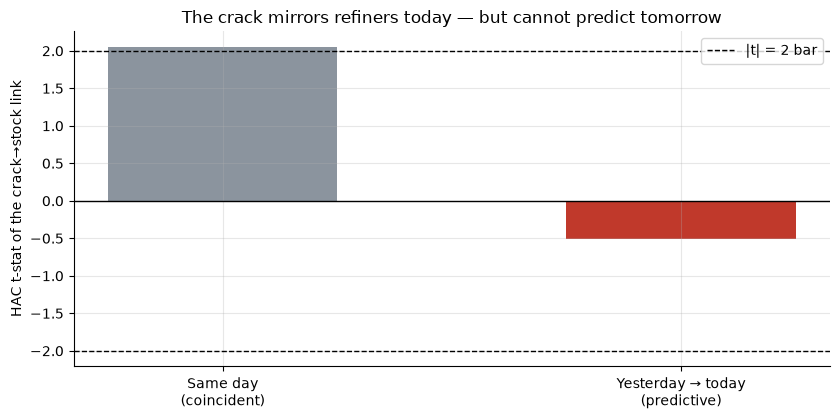

[REAL tape]  same-day t=+2.06   predictive t=-0.51


In [2]:
if HAVE_REAL:
    f = real_tape()
    pred = st.predictive_regression(f); coin = st.contemporaneous_regression(f)
    coin_t, pred_t = coin['tstat'], pred['tstat']
    tape = 'REAL tape'
else:
    coin_t, pred_t = 2.06, -0.51
    tape = 'frozen real numbers (docs/results.md)'
fig, ax = plt.subplots(figsize=(8.5, 4.3))
b = ax.bar(['Same day\n(coincident)', 'Yesterday → today\n(predictive)'],
           [coin_t, pred_t], color=[GREY, RED], width=.5)
ax.axhline(2, ls='--', c='k', lw=1, label='|t| = 2 bar')
ax.axhline(-2, ls='--', c='k', lw=1); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t-stat of the crack→stock link'); ax.legend()
ax.set_title('The crack mirrors refiners today — but cannot predict tomorrow')
plt.tight_layout(); plt.show()
print(f'[{tape}]  same-day t={coin_t:+.2f}   predictive t={pred_t:+.2f}')

There's the whole story in one chart. The **same-day** link clears the bar (*t* = +2.06) — refiners obviously track their own margin. But the **predictive** link is dead (*t* = -0.51): yesterday's crack tells you nothing about today's stock. The signal everyone 'sees' is the mirror, not a forecast.

**Now: does a crack-timer beat just holding the basket?** Two natural rules — long when the crack is above its trailing median, and long when it's been rising — vs buy-and-hold.

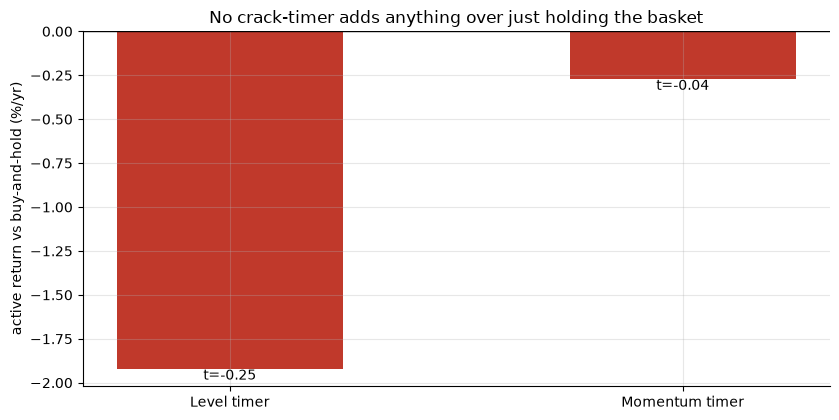

Level active -1.92%/yr (t=-0.25)   Momentum active -0.27%/yr (t=-0.04)


In [3]:
if HAVE_REAL:
    f = real_tape()
    lvl = st.summarize_timer(f, st.level_signal(f['crack']))
    mom = st.summarize_timer(f, st.momentum_signal(f['crack'], 20))
    vals = [lvl['active_ann'], mom['active_ann']]
    ts = [lvl['active_t'], mom['active_t']]
else:
    vals = [-1.92, -0.27]
    ts = [-0.25, -0.04]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
b = ax.bar(['Level timer', 'Momentum timer'], vals,
           color=[RED if v <= 0 else AMBER for v in vals], width=.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('active return vs buy-and-hold (%/yr)')
ax.set_title('No crack-timer adds anything over just holding the basket')
for bar_, t_ in zip(b, ts):
    ax.annotate(f't={t_:+.2f}', (bar_.get_x()+bar_.get_width()/2,
        bar_.get_height()), ha='center', va='bottom' if bar_.get_height()>=0 else 'top')
plt.tight_layout(); plt.show()
print(f'Level active {vals[0]:+.2f}%/yr (t={ts[0]:+.2f})   Momentum active {vals[1]:+.2f}%/yr (t={ts[1]:+.2f})')

Both timers *underperform* buy-and-hold on the active return (level -1.9%/yr, momentum -0.3%/yr), and neither is statistically distinguishable from zero. A 'rising margins' rule gives you nothing you didn't already have by simply owning the refiners.

## 5 · The verdict

- **Signal — None.** Yesterday's crack change doesn't forecast today's refiner return (*t* = -0.51, R² ≈ 0.0001). The only real link is *same-day*, which you can't trade.
- **Tradability — Mirage.** No crack-timer beats buy-and-hold; the best gross edge (+1.7%/yr) is noise and dies at the first cost.
- **Coincident ≠ predictive — Confirmed.** The crack *is* the margin in real time, so it mirrors the stock. Mistaking that mirror for a crystal ball is the entire illusion.

## 6 · Could you actually trade it?

There's no gross edge to protect, so costs only make it worse. Here's the momentum timer's active return as you charge realistic round-trip costs:

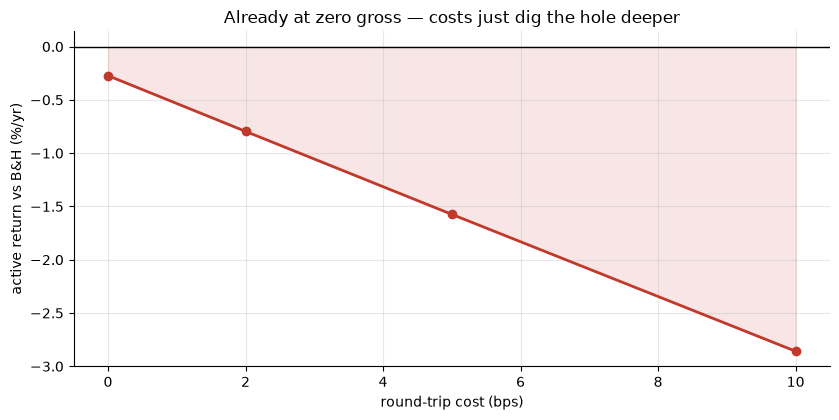

Active return: -0.27%/yr gross -> -2.86%/yr at 10 bps


In [4]:
costs = [0.0, 2.0, 5.0, 10.0]
if HAVE_REAL:
    f = real_tape(); pos = st.momentum_signal(f['crack'], 20)
    net = [st.summarize_timer(f, pos, cost_bps=c)['active_ann'] for c in costs]
else:
    net = [-0.27, -0.8, -1.57, -2.86]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, color=RED, alpha=.12)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('active return vs B&H (%/yr)')
ax.set_title('Already at zero gross — costs just dig the hole deeper')
plt.tight_layout(); plt.show()
print(f'Active return: {net[0]:+.2f}%/yr gross -> {net[-1]:+.2f}%/yr at 10 bps')

Even gross, the timer is at -0.3%/yr active; by 10 bps it's -2.9%/yr. Unlike a real-but-fragile signal, there's nothing here to salvage — the crack-timer is a mirage from the first dollar.

## 7 · Going further

- **The same trap, elsewhere.** Any 'X moves with Y, so X predicts Y' story deserves the lag test we ran here. See [Study 226 — Crude-Seasonality](../../226-crude-seasonality/) and [Study 132 — Yield-Curve-Steepener](../../132-yield-curve-steepener/) for the same discipline applied to other commodity/curve claims.
- **Could a *weekly* crack lead?** We tested daily. Some argue refining margins matter at a slower frequency; a fork could test weekly EIA crack data against weekly returns (beware of far fewer observations).
- **The hedging angle.** The crack's real job is to *hedge* a refiner's margin, not time the stock. That's a genuine use — just not the one being marketed.

*Think there's a slower-moving lead we missed? Fork this, change the horizon, and show a lagged crack→refiner link that clears |t| = 2 out of sample.*